# Libraries

In [213]:
import pandas as pd
import numpy as np

import pymc as pm
import bambi as bm
import statsmodels.api as sm
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS
from linearmodels.iv import IV2SLS

from scipy.stats import gaussian_kde
from tableone import TableOne

import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

from stargazer.stargazer import Stargazer

# Data

In [161]:
df_dem = pd.read_csv("Data/Base_de_Datos_Demograficos.csv")
df_dem.rename(columns={'sucessfull': 'successful',
                      'last_semester': 'LastSem'}, inplace = True)
df_coin = pd.read_csv("Data/Base_de_Datos_Estudiantes.csv")
df_coin.rename(columns={'Subject': 'ID', 
                       'succesfull': 'successful',
                       'last_semester': 'LastSem',
                       "Answer_agree_driver_sanction" : "DriverSanction",
                       "why_did_you_decide_to_study_the_career_you_are_studying?" : "ReasonUndergrad"}, inplace = True)
#the next df is without the 7 subjects who we did not properly randomize
df_coin_wo = pd.read_csv("Data/Base_de_Datos_Estudiantes_eleccion_100_aleatorio.csv")
df_coin_wo.rename(columns={'Subject': 'ID',
                           'succesfull': 'successful',
                           'last_semester': 'LastSem',
                          "Answer_agree_driver_sanction" : "DriverSanction",
                          "why_did_you_decide_to_study_the_career_you_are_studying?" : "ReasonUndergrad"}, inplace = True)

# Merge and drop duplicate columns
df_coin = pd.merge(df_dem, df_coin, on='ID', suffixes=('', '_dup'))
df_coin_wo = pd.merge(df_dem, df_coin_wo, on='ID', suffixes=('', '_dup'))

# Drop the duplicate column from df2
df_coin = df_coin.loc[:, ~df_coin.columns.str.endswith('_dup')]
df_coin_wo = df_coin_wo.loc[:, ~df_coin_wo.columns.str.endswith('_dup')]

df_coin.rename(columns={'age': 'Age'}, inplace = True)
df_coin_wo.rename(columns={'age': 'Age'}, inplace = True)

[df_dem.shape, df_coin.shape, df_coin_wo.shape]


[(96, 18), (96, 21), (89, 21)]

In [162]:
df_coin['SES'] = df_coin['social'].replace({'Estrato 1': 1, 'Estrato 2': 2, 'Estrato 3': 3, 
                                            'Estrato 4': 4, 'Estrato 5': 5, 'Estrato 6': 6})
df_coin['EdFather'] = df_coin['dad_career'].replace({'Bachillerato': 0, 'Tecnico o Tecnologo ': 1, 'Titulo Universitario ': 2, 
                                                     'Especializacion': 3, 'Maestria': 4, 'Doctorado': 5})
df_coin['EdMother'] = df_coin['mom_career'].replace({'Bachillerato': 0, 'Tecnico o Tecnologo ': 1, 'Titulo Universitario ': 2,
                                                     'Especializacion': 3, 'Maestria': 4, 'Doctorado': 5})
df_coin['gender'] = df_coin['gender'].replace({'Masculino': 0, 'Femenino': 1})
df_coin.rename(columns={'gender': 'Female'}, inplace = True)
df_coin['career'] = df_coin['career'].replace({'Economia': "Econ", 'Administracion': "Business",
                                              "Contabilidad": "Accounting", "Finanzas": "Finance"})
df_coin['ReasonUndergrad'] = df_coin['ReasonUndergrad'].replace({'Interes social politico y economico': "SocietyPolitics", 
                                                                 'Oferta en el mercado laboral': "JobProspect",
                                                                 "Le gusta la carrera": "LikesUndergrad", 
                                                                 "Se destaca en la materia": "GoodAt"})
df_coin['StudentIncome'] = df_coin['earns'].replace({'Menor a 99.999' : 0,
                                                     'Entre 100.000 a 300.000': 1,
                                                     'Entre 300.001 a 500.000': 2,
                                                     'Entre 500.001 a 800.000': 3,
                                                     'Entre 800.001 a 1.000.000': 4,
                                                     'Entre 1.000.001 a 1.300.000': 5,
                                                     'Mayor a 1.300.001': 6})


df_coin_wo['SES'] = df_coin_wo['social'].replace({'Estrato 1': 1, 'Estrato 2': 2, 'Estrato 3': 3, 
                                                  'Estrato 4': 4, 'Estrato 5': 5, 'Estrato 6': 6})
df_coin_wo['EdFather'] = df_coin_wo['dad_career'].replace({'Bachillerato': 0, 'Tecnico o Tecnologo ': 1, 'Titulo Universitario ': 2, 
                                                           'Especializacion': 3, 'Maestria': 4, 'Doctorado': 5})
df_coin_wo['EdMother'] = df_coin_wo['mom_career'].replace({'Bachillerato': 0, 'Tecnico o Tecnologo ': 1, 'Titulo Universitario ': 2, 
                                                           'Especializacion': 3, 'Maestria': 4, 'Doctorado': 5})
df_coin_wo['gender'] = df_coin_wo['gender'].replace({'Masculino': 0, 'Femenino': 1})
df_coin_wo.rename(columns={'gender': 'Female'}, inplace = True)
df_coin_wo['career'] = df_coin_wo['career'].replace({'Economia': "Econ", 'Administracion': "Business",
                                              "Contabilidad": "Accounting", "Finanzas": "Finance"})
df_coin_wo['ReasonUndergrad'] = df_coin_wo['ReasonUndergrad'].replace({'Interes social politico y economico': "SocietyPolitics", 
                                                                 'Oferta en el mercado laboral': "JobProspect",
                                                                 "Le gusta la carrera": "LikesUndergrad", 
                                                                 "Se destaca en la materia": "GoodAt"})
df_coin_wo['StudentIncome'] = df_coin_wo['earns'].replace({'Menor a 99.999' : 0,
                                                     'Entre 100.000 a 300.000': 1,
                                                     'Entre 300.001 a 500.000': 2,
                                                     'Entre 500.001 a 800.000': 3,
                                                     'Entre 800.001 a 1.000.000': 4,
                                                     'Entre 1.000.001 a 1.300.000': 5,
                                                     'Mayor a 1.300.001': 6})

df_coin.rename(columns={'career': 'Career'}, inplace = True)
df_coin_wo.rename(columns={'career': 'Career'}, inplace = True)

C:\Users\L03552670\AppData\Local\Temp\ipykernel_22028\3670630645.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_coin['SES'] = df_coin['social'].replace({'Estrato 1': 1, 'Estrato 2': 2, 'Estrato 3': 3,
C:\Users\L03552670\AppData\Local\Temp\ipykernel_22028\3670630645.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_coin['EdFather'] = df_coin['dad_career'].replace({'Bachillerato': 0, 'Tecnico o Tecnologo ': 1, 'Titulo Universitario ': 2,
C:\Users\L03552670\AppData\Local\Temp\ipykernel_22028\3670630645.py:5: FutureWarnin

# Analyses

In [203]:


# Define categorical and continuous columns
columns = ["Age", "Female", "SES", "StudentIncome", "EdFather", "EdMother", "DriverSanction", "Career", "ReasonUndergrad"]
categorical = ["Career", "ReasonUndergrad"]

# Create the table
table = TableOne(df_coin_wo, columns=columns, categorical=categorical, groupby="LastSem", pval = True)
table.to_excel('Tablas/mydems.xlsx')
print(table.tabulate(tablefmt = "fancy_grid"))

╒═══════════════════════════╤═════════════════╤═══════════╤════════════╤════════════╤════════════╤═══════════╕
│                           │                 │ Missing   │ Overall    │ 0          │ 1          │ P-Value   │
╞═══════════════════════════╪═════════════════╪═══════════╪════════════╪════════════╪════════════╪═══════════╡
│ n                         │                 │           │ 89         │ 48         │ 41         │           │
├───────────────────────────┼─────────────────┼───────────┼────────────┼────────────┼────────────┼───────────┤
│ Age, mean (SD)            │                 │ 0         │ 19.1 (2.4) │ 17.2 (0.8) │ 21.2 (1.5) │ <0.001    │
├───────────────────────────┼─────────────────┼───────────┼────────────┼────────────┼────────────┼───────────┤
│ Female, mean (SD)         │                 │ 0         │ 0.5 (0.5)  │ 0.5 (0.5)  │ 0.5 (0.5)  │ 0.468     │
├───────────────────────────┼─────────────────┼───────────┼────────────┼────────────┼────────────┼───────────┤
│

In [186]:
df_coin_wo.dtypes

ID                                                                object
Treatment                                                          int64
successful                                                         int64
Age                                                                int64
Female                                                             int64
Career                                                            object
semester                                                           int64
LastSem                                                            int64
social                                                            object
dad_career                                                        object
mom_career                                                        object
earns                                                             object
_ERO                                                              object
_TO                                                

In [131]:
est = smf.ols("successful ~ Treatment*LastSem", data = df_coin_wo).fit(cov_type = "HC3")
est2 = smf.ols("successful ~ Treatment*LastSem + Age + Female + Career + SES + StudentIncome + EdFather + EdMother + DriverSanction + ReasonUndergrad",  data = df_coin_wo).fit(cov_type = "HC3")

stargazer = Stargazer([est, est2])
stargazer.significant_digits(2)
stargazer.show_confidence_intervals(True)
stargazer.covariate_order(["Intercept", 'Treatment', 'LastSem', 'Treatment:LastSem', 'Age', 
                           'Female', 'SES', "StudentIncome", 'DriverSanction',  
                           'Career[T.Business]',
                           'Career[T.Econ]',
                           'Career[T.Finance]',
                           'EdFather',
                           'EdMother',
                           'ReasonUndergrad[T.JobProspect]',
                           'ReasonUndergrad[T.LikesUndergrad]',
                           'ReasonUndergrad[T.SocietyPolitics]'])

stargazer


In [135]:
print(stargazer.render_latex())

## Bayesian

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 115 seconds.


<Axes: title={'center': 'theta'}>

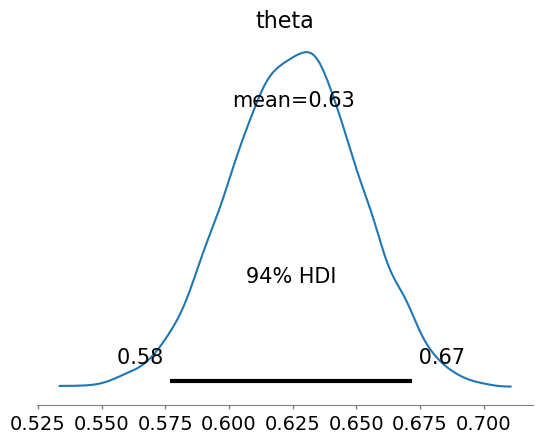

In [138]:
# Observed data
n = 4 * df_coin_wo["ID"].unique().shape[0]   # number of trials. Four tosses times n subjects
k = df_coin_wo["successful"].sum()    # number of successes

with pm.Model() as model:
    # Prior
    theta = pm.Beta("theta", alpha=1, beta=1)  # Uniform prior over [0, 1]

    # Likelihood
    y = pm.Binomial("y", n=n, p=theta, observed=k)

    # Inference
    trace = pm.sample(2000, return_inferencedata=True)



In [ ]:
# Posterior Summary
az.summary(trace, var_names=["theta"])
az.plot_posterior(trace, var_names=["theta"])

In [139]:
df_coin_wo.columns

Index(['ID', 'Treatment', 'successful', 'Age', 'Female', 'Career', 'semester',
       'LastSem', 'social', 'dad_career', 'mom_career', 'earns', '_ERO', '_TO',
       '_CONS', '_EST', '_PA',
       '¿Le_parecio_muy_dificil_responder_las_preguntas?', 'DriverSanction',
       'The_phrase_you_look_prettier_when_you_are_quiet_means_to_you',
       'ReasonUndergrad', 'SES', 'EdFather', 'EdMother', 'StudentIncome'],
      dtype='object')

In [143]:
df_coin_wo.loc[idx_last_sem & idx_treat,"ID"].unique().shape[0]

24

In [153]:
# Observed data
idx_last_sem = df_coin_wo["LastSem"] == 1
idx_treat = df_coin_wo["Treatment"] == 1

n_last_sem_treat = 4 * df_coin_wo.loc[idx_last_sem & idx_treat,"ID"].unique().shape[0]  #n_tosses
k_last_sem_treat = df_coin_wo.loc[idx_last_sem & idx_treat, "successful"].sum()    # number of successes

n_last_sem_control = 4 * df_coin_wo.loc[idx_last_sem & (~idx_treat),"ID"].unique().shape[0]  #n_tosses
k_last_sem_control = df_coin_wo.loc[idx_last_sem & (~idx_treat), "successful"].sum()    # number of successes


n_first_sem_treat = 4 * df_coin_wo.loc[(~idx_last_sem) & idx_treat,"ID"].unique().shape[0]  #n_tosses
k_first_sem_treat = df_coin_wo.loc[(~idx_last_sem) & idx_treat, "successful"].sum()    # number of successes

n_first_sem_control = 4 * df_coin_wo.loc[(~idx_last_sem) & (~idx_treat),"ID"].unique().shape[0]  #n_tosses
k_first_sem_control = df_coin_wo.loc[(~idx_last_sem) & (~idx_treat), "successful"].sum()    # number of successes

with pm.Model() as model:
    # Prior
    theta_l_t = pm.Beta("theta_l_t", alpha=1, beta=1) #last semester treat  
    theta_l_c = pm.Beta("theta_l_c", alpha=1, beta=1) #last semester control 
    theta_f_t = pm.Beta("theta_f_t", alpha=1, beta=1) #first semester treat 
    theta_f_c = pm.Beta("theta_f_c", alpha=1, beta=1) #first semester control

    effect_LS = pm.Deterministic("Effect_LS", theta_l_t - theta_l_c) #Treatment effect last semester
    effect_FS = pm.Deterministic("Effect_FS", theta_f_t - theta_f_c) #Treatment effect first semester

    effect_Overall = pm.Deterministic("Semester_Effect", effect_LS - effect_FS)
    
    # Likelihood
    y_l_t = pm.Binomial("y_l_t", n=n_last_sem_treat, p=theta_l_t, observed=k_last_sem_treat)
    y_l_c = pm.Binomial("y_l_c", n=n_last_sem_control, p=theta_l_c, observed=k_last_sem_control)
    y_f_l = pm.Binomial("y_f_l", n=n_first_sem_treat, p=theta_f_t, observed=k_first_sem_treat)
    y_f_c = pm.Binomial("y_f_c", n=n_first_sem_control, p=theta_f_c, observed=k_first_sem_control)

    # Inference
    trace = pm.sample(2000, return_inferencedata=True)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta_l_t, theta_l_c, theta_f_t, theta_f_c]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 111 seconds.


                  mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
Effect_FS       -0.061  0.068  -0.193    0.064      0.001    0.001   12969.0   
Effect_LS       -0.029  0.075  -0.165    0.120      0.001    0.001   13650.0   
Semester_Effect  0.032  0.102  -0.155    0.228      0.001    0.001   12670.0   
theta_f_c        0.653  0.048   0.560    0.739      0.000    0.000   14740.0   
theta_f_t        0.592  0.049   0.502    0.686      0.000    0.000   11411.0   
theta_l_c        0.642  0.056   0.537    0.746      0.000    0.000   14620.0   
theta_l_t        0.613  0.049   0.521    0.704      0.000    0.000   12322.0   

                 ess_tail  r_hat  
Effect_FS          6569.0    1.0  
Effect_LS          7000.0    1.0  
Semester_Effect    6419.0    1.0  
theta_f_c          6614.0    1.0  
theta_f_t          6349.0    1.0  
theta_l_c          6753.0    1.0  
theta_l_t          6388.0    1.0  


<Axes: title={'center': 'Semester_Effect'}>

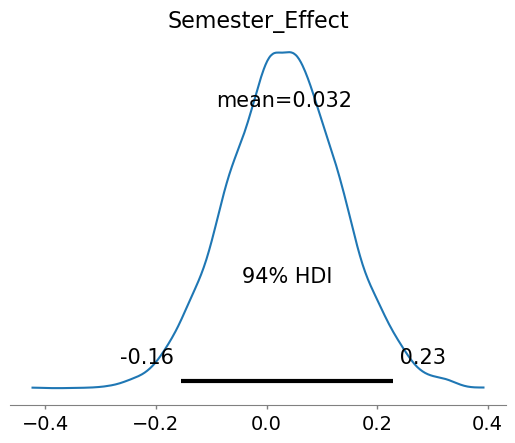

In [155]:
print(az.summary(trace))
az.plot_posterior(trace, var_names=["Semester_Effect"])

## Bayesian Regression

In [205]:
# Create and fit the model
model = bm.Model("successful ~ Treatment*LastSem + Age + Female + Career + SES + StudentIncome + EdFather + EdMother + DriverSanction + ReasonUndergrad", 
                  data=df_coin_wo)
results = model.fit()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, Treatment, LastSem, Treatment:LastSem, Age, Female, Career, SES, StudentIncome, EdFather, EdMother, DriverSanction, ReasonUndergrad]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 206 seconds.


In [206]:
az.summary(results, round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Age,-0.28,0.10,-0.45,-0.09,0.00,0.00,3901.54,3101.51,1.0
Career[Business],-0.68,0.42,-1.45,0.10,0.01,0.01,3351.51,2883.27,1.0
Career[Econ],-0.81,0.45,-1.64,0.01,0.01,0.01,3460.29,2874.02,1.0
Career[Finance],-0.32,0.57,-1.40,0.75,0.01,0.01,3538.77,3187.72,1.0
DriverSanction,0.06,0.04,-0.02,0.14,0.00,0.00,5129.72,3273.69,1.0
EdFather,0.07,0.09,-0.11,0.24,0.00,0.00,5318.60,3133.48,1.0
EdMother,-0.10,0.11,-0.32,0.11,0.00,0.00,5255.44,3323.88,1.0
Female,0.21,0.23,-0.24,0.63,0.00,0.00,5505.58,2866.21,1.0
Intercept,7.10,1.68,3.91,10.15,0.03,0.02,4163.84,2783.25,1.0
LastSem,0.87,0.49,-0.10,1.74,0.01,0.01,3381.46,3020.25,1.0


In [224]:
posterior_df = az.extract(results)
posterior_df

<xarray.Dataset>
Dimensions:              (sample: 4000, Career_dim: 3, ReasonUndergrad_dim: 3)
Coordinates:
  * Career_dim           (Career_dim) <U8 'Business' 'Econ' 'Finance'
  * ReasonUndergrad_dim  (ReasonUndergrad_dim) <U15 'JobProspect' ... 'Societ...
  * sample               (sample) object MultiIndex
  * chain                (sample) int32 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3
  * draw                 (sample) int32 0 1 2 3 4 5 ... 994 995 996 997 998 999
Data variables: (12/14)
    Age                  (sample) float64 -0.2732 -0.2724 ... -0.3565 -0.335
    Career               (Career_dim, sample) float64 -0.6719 -0.2687 ... 0.1095
    DriverSanction       (sample) float64 0.1133 0.06581 ... 0.04816 -0.03529
    EdFather             (sample) float64 0.1561 0.2188 ... 0.0661 0.2151
    EdMother             (sample) float64 -0.1405 -0.1002 ... -0.2603 -0.1772
    Female               (sample) float64 0.3162 0.1957 0.2655 ... 0.5346 0.3264
    ...                   ...
    ReasonUndergrad      (ReasonUndergrad_dim, sample) float64 0.8352 ... 0.5341
    SES                  (sample) float64 -0.05845 -0.1175 ... -0.0547 -0.1696
    StudentIncome        (sample) float64 0.2739 0.4363 0.2666 ... 0.3563 0.4252
    Treatment            (sample) float64 -0.2374 -0.1016 ... -0.5472 -0.3041
    Treatment:LastSem    (sample) float64 -0.09562 -0.1003 ... 0.4217 0.183
    sigma                (sample) float64 0.976 0.893 0.8588 ... 0.8601 0.8216
Attributes:
    created_at:                  2025-04-06T11:56:45.405391+00:00
    arviz_version:               0.18.0
    inference_library:           pymc
    inference_library_version:   5.17.0
    sampling_time:               206.16738390922546
    tuning_steps:                1000
    modeling_interface:          bambi
    modeling_interface_version:  0.14.0

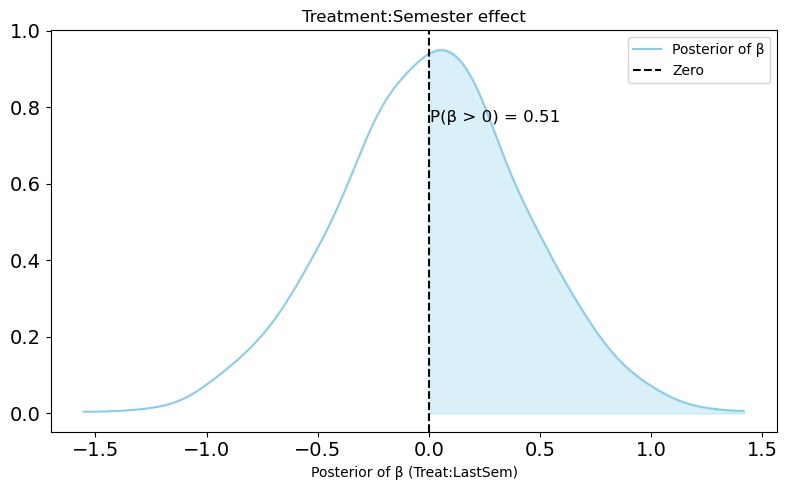

In [232]:
plt.figure(figsize=(8, 5))
# The variable name may vary depending on your reference level
beta = np.array(posterior_df["Treatment:LastSem"])

# Plot the posterior density
az.plot_kde(beta, bw=0.1, label="Posterior of β", plot_kwargs={"color": "skyblue"})

# Vertical line at 0
plt.axvline(0, color="black", linestyle="--", label="Zero")

# Calculate P(β > 0) or P(β < 0) i.e. see the effect and change
prob = (beta > 0).mean()

# Shade area > 0 (or <0)
kde = gaussian_kde(beta, bw_method=0.225) #Change bw_method for better shading
x_vals = np.linspace(beta.min(), beta.max(), 1000)
y_vals = y_vals = kde(x_vals)
plt.fill_between(x_vals, y_vals, where=(x_vals > 0), color="skyblue", alpha=0.3)

# Add text
plt.text(beta.mean(), max(y_vals) * 0.8, f"P(β > 0) = {prob:.2f}", fontsize=12)

plt.xlabel("Posterior of β (Treat:LastSem)")
plt.title("Treatment:Semester effect")
plt.legend()
plt.tight_layout()
plt.show()
